In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from arc_agi2_fun.data import load_official_split
from arc_agi2_fun.tensors import (
    NUM_COLORS,
    evaluate_tensor,
    get_task_grid,
    grid_to_tensor,
    tensor_to_grid,
)
from arc_agi2_fun.visualize import plot_grid, plot_task

DATA_DIR = ROOT / 'data' / 'ARC-AGI-2'
print('repo:', ROOT)
print('data:', DATA_DIR)

repo: /home/logankelsch/logxco/competitions/ARC-AGI-2_For_Fun
data: /home/logankelsch/logxco/competitions/ARC-AGI-2_For_Fun/data/ARC-AGI-2


1000 tasks loaded from training
first 20 ids: ['00576224', '007bbfb7', '009d5c81', '00d62c1b', '00dbd492', '017c7c7b', '025d127b', '03560426', '045e512c', '0520fde7', '05269061', '05a7bcf2', '05f2a901', '0607ce86', '0692e18c', '06df4c85', '070dd51e', '08ed6ac7', '09629e4f', '0962bcdd']
selected: 009d5c81
train examples: 5
test examples: 1


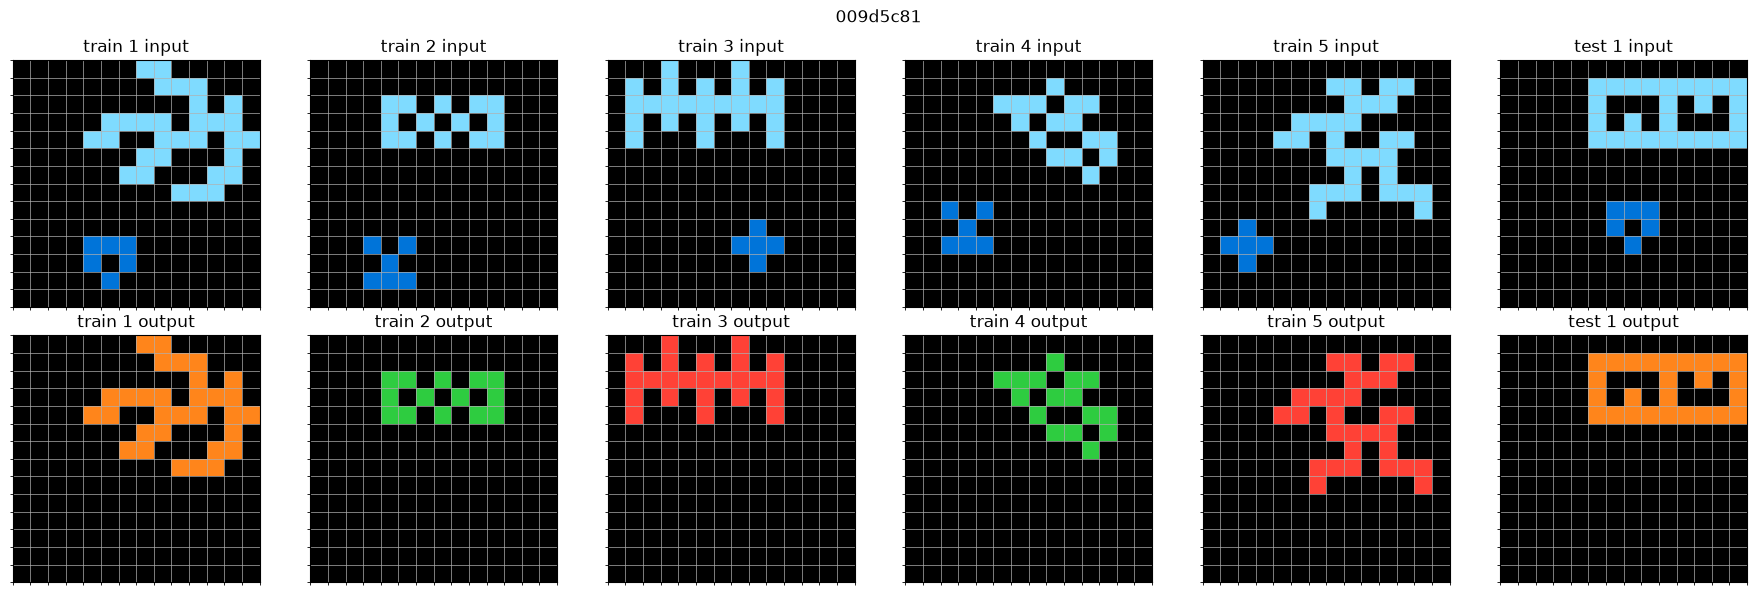

In [2]:
SPLIT = 'training'  # 'training' or 'evaluation'

tasks = load_official_split(DATA_DIR, SPLIT)
task_ids = list(tasks)
print(f'{len(task_ids)} tasks loaded from {SPLIT}')
print('first 20 ids:', task_ids[:20])

for i in range(2,3):
    TASK_ID = task_ids[i]  # replace with any id printed above
    task = tasks[TASK_ID]
    print('selected:', TASK_ID)
    print('train examples:', len(task.train))
    print('test examples:', len(task.test_inputs))

    plot_task(task)
    plt.show()

In [3]:
from ops import (
    init_env,
    GP_generate,
    SP_generate,
    get_GP_pool,
    get_ST_unsovled_frontier,
)

import pandas as pd


# --------------------------------------------------
# Initialize environment from task.train
# --------------------------------------------------

GP_meta, GP_X, SP_meta, SP_X, ST = init_env(task.train)


# --------------------------------------------------
# Expand GP by 10 genes
# --------------------------------------------------

new_gp_gidx = GP_generate(
    GP_meta,
    GP_X,
    n_new_genes=60,
    rng=42,
)


# --------------------------------------------------
# Perform one SP generation step
# --------------------------------------------------

new_sp_gidx = SP_generate(
    SP_meta,
    SP_X,
    ST,
    rng=42,
)


# --------------------------------------------------
# Show current Boolean Solution Tree
# --------------------------------------------------

display(
    pd.DataFrame(ST.rows()).set_index("node_id")
)

,label,sp_gidx,op,dims,source,gp_gidx,solution_rule,solution_params,directly_solved,solved,needs_gp_solution,derivation
node_id,,,,,,,,,,,,
0,root,0.0,raw_output,2,-1.0,-1,None,{},False,False,False,((inv_partition_shape✓ AND shape AND composite...
1,h,1.0,partition_shape,0,0.0,-1,None,{},False,False,True,NaN
2,w,2.0,partition_shape,0,0.0,-1,None,{},False,False,True,NaN
3,sp_3:partition_composite,3.0,partition_composite,0,0.0,-1,None,{},False,False,True,NaN
4,sp_4:partition_composite,4.0,partition_composite,2,0.0,-1,None,{},False,False,True,NaN
5,sp_5:partition_composite,5.0,partition_composite,0,0.0,-1,None,{},False,False,True,NaN
6,sp_6:partition_composite,6.0,partition_composite,2,0.0,-1,None,{},False,False,True,NaN
7,sp_7:partition_composite,7.0,partition_composite,0,0.0,-1,None,{},False,False,True,NaN
8,sp_8:partition_composite,8.0,partition_composite,2,0.0,-1,None,{},False,False,True,NaN


In [4]:
# --------------------------------------------------
# Retrieve complete computation / matching pools
# --------------------------------------------------

GP_pool = get_GP_pool(
    GP_meta,
    GP_X,
    max_dim=0
)

ST_frontier = get_ST_unsovled_frontier(
    ST,
    SP_X,
    max_dim=0
)

In [5]:
print(len(GP_pool))
for i in range(len(GP_pool)):
    print((GP_pool[i].astype(float)))

print()
print(len(ST_frontier))
for i in range(len(ST_frontier)):
    print((ST_frontier[i].astype(float)))

15
[14. 14. 14. 14. 14.]
[14. 14. 14. 14. 14.]
[0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1.]
[8. 8. 8. 8. 8.]
[10. 10.  9.  8.  9.]
[4. 3. 7. 2. 1.]
[0. 1. 2. 1. 2.]
[0. 2. 0. 1. 1.]
[4. 4. 1. 5. 4.]
[159. 176. 167. 174. 161.]
[8. 3. 5. 6. 8.]
[10.  7.  9.  7.  9.]
[0. 1. 0. 2. 0.]
[0. 3. 0. 5. 0.]

6
[14. 14. 14. 14. 14.]
[14. 14. 14. 14. 14.]
[0. 0. 0. 0. 0.]
[2. 2. 2. 2. 2.]
[3. 3. 3. 3. 3.]
[7. 7. 7. 7. 7.]


In [6]:
from ops import (
    get_GP_pool,
    get_ST_unsovled_frontier,
    solve_0dim_1gene_basic,
)

import pandas as pd


GP_pool_0d = get_GP_pool(
    GP_meta,
    GP_X,
    min_dim=0,
    max_dim=0,
)

ST_frontier_0d = get_ST_unsovled_frontier(
    ST,
    SP_X,
    min_dim=0,
    max_dim=0,
)


solutions = solve_0dim_1gene_basic(
    GP_pool_0d,
    ST_frontier_0d,
    GP_X=GP_X,
    SP_X=SP_X,
    ST=ST,
)


display(
    pd.DataFrame(ST.rows()).set_index("node_id")
)

,label,sp_gidx,op,dims,source,gp_gidx,solution_rule,solution_params,directly_solved,solved,needs_gp_solution,derivation
node_id,,,,,,,,,,,,
0,root,0.0,raw_output,2,-1.0,-1,NaN,{},False,False,False,((inv_partition_shape✓ AND shape AND composite...
1,h,1.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
2,w,2.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
3,sp_3:partition_composite,3.0,partition_composite,0,0.0,3,identity,{},True,True,False,NaN
4,sp_4:partition_composite,4.0,partition_composite,2,0.0,-1,NaN,{},False,False,True,NaN
5,sp_5:partition_composite,5.0,partition_composite,0,0.0,5,add_constant,{'c': 1},True,True,False,NaN
6,sp_6:partition_composite,6.0,partition_composite,2,0.0,-1,NaN,{},False,False,True,NaN
7,sp_7:partition_composite,7.0,partition_composite,0,0.0,5,add_constant,{'c': 2},True,True,False,NaN
8,sp_8:partition_composite,8.0,partition_composite,2,0.0,-1,NaN,{},False,False,True,NaN


In [7]:
ST_frontier = get_ST_unsovled_frontier(
    ST,
    SP_X,
)

print(len(ST_frontier))

15


In [8]:
print((SP_X[4][0]))

[[ True  True  True  True  True  True  True False False  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True False False False  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True False  True
  False  True]
 [ True  True  True  True  True False False False False  True False False
  False  True]
 [ True  True  True  True False False  True  True False False False  True
  False False]
 [ True  True  True  True  True  True  True False False  True  True  True
  False  True]
 [ True  True  True  True  True  True False False  True  True  True False
  False  True]
 [ True  True  True  True  True  True  True  True  True False False False
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True]
 [ True  True  True  

In [9]:
from ops import (
    get_GP_pool,
    get_ST_unsovled_frontier,
    solve_2dim_1gene_basic,
)

import pandas as pd


# 2D boolean candidate genes generated from the input side
GP_pool_2d_bool = get_GP_pool(
    GP_meta,
    GP_X,
    min_dim=2,
    max_dim=2,
    dtype=bool,
)


# Unresolved 2D boolean targets on the solution side
ST_frontier_2d_bool = get_ST_unsovled_frontier(
    ST,
    SP_X,
    min_dim=2,
    max_dim=2,
    dtype=bool,
)


# Attempt exact minimum-complexity spatial solutions
solutions_2d = solve_2dim_1gene_basic(
    GP_pool_2d_bool,
    ST_frontier_2d_bool,
    GP_X=GP_X,
    SP_X=SP_X,
    ST=ST,
)


# Inspect discovered relationships
for solution in solutions_2d:
    print(
        f"SP {solution.sp_gidx} <- GP {solution.gp_gidx}: "
        f"{solution.expression}"
    )


# Inspect updated Boolean solution structure
display(
    pd.DataFrame(ST.rows()).set_index("node_id")
)

SP 4 <- GP 40: Y = X
SP 11 <- GP 4: Y = X
SP 12 <- GP 6: Y = X
SP 19 <- GP 8: Y = X


,label,sp_gidx,op,dims,source,gp_gidx,solution_rule,solution_params,directly_solved,solved,needs_gp_solution,derivation
node_id,,,,,,,,,,,,
0,root,0.0,raw_output,2,-1.0,-1,NaN,{},False,False,False,((inv_partition_shape✓ AND shape AND composite...
1,h,1.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
2,w,2.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
3,sp_3:partition_composite,3.0,partition_composite,0,0.0,3,identity,{},True,True,False,NaN
4,sp_4:partition_composite,4.0,partition_composite,2,0.0,40,identity,{},True,True,False,NaN
5,sp_5:partition_composite,5.0,partition_composite,0,0.0,5,add_constant,{'c': 1},True,True,False,NaN
6,sp_6:partition_composite,6.0,partition_composite,2,0.0,-1,NaN,{},False,False,True,NaN
7,sp_7:partition_composite,7.0,partition_composite,0,0.0,5,add_constant,{'c': 2},True,True,False,NaN
8,sp_8:partition_composite,8.0,partition_composite,2,0.0,-1,NaN,{},False,False,True,NaN




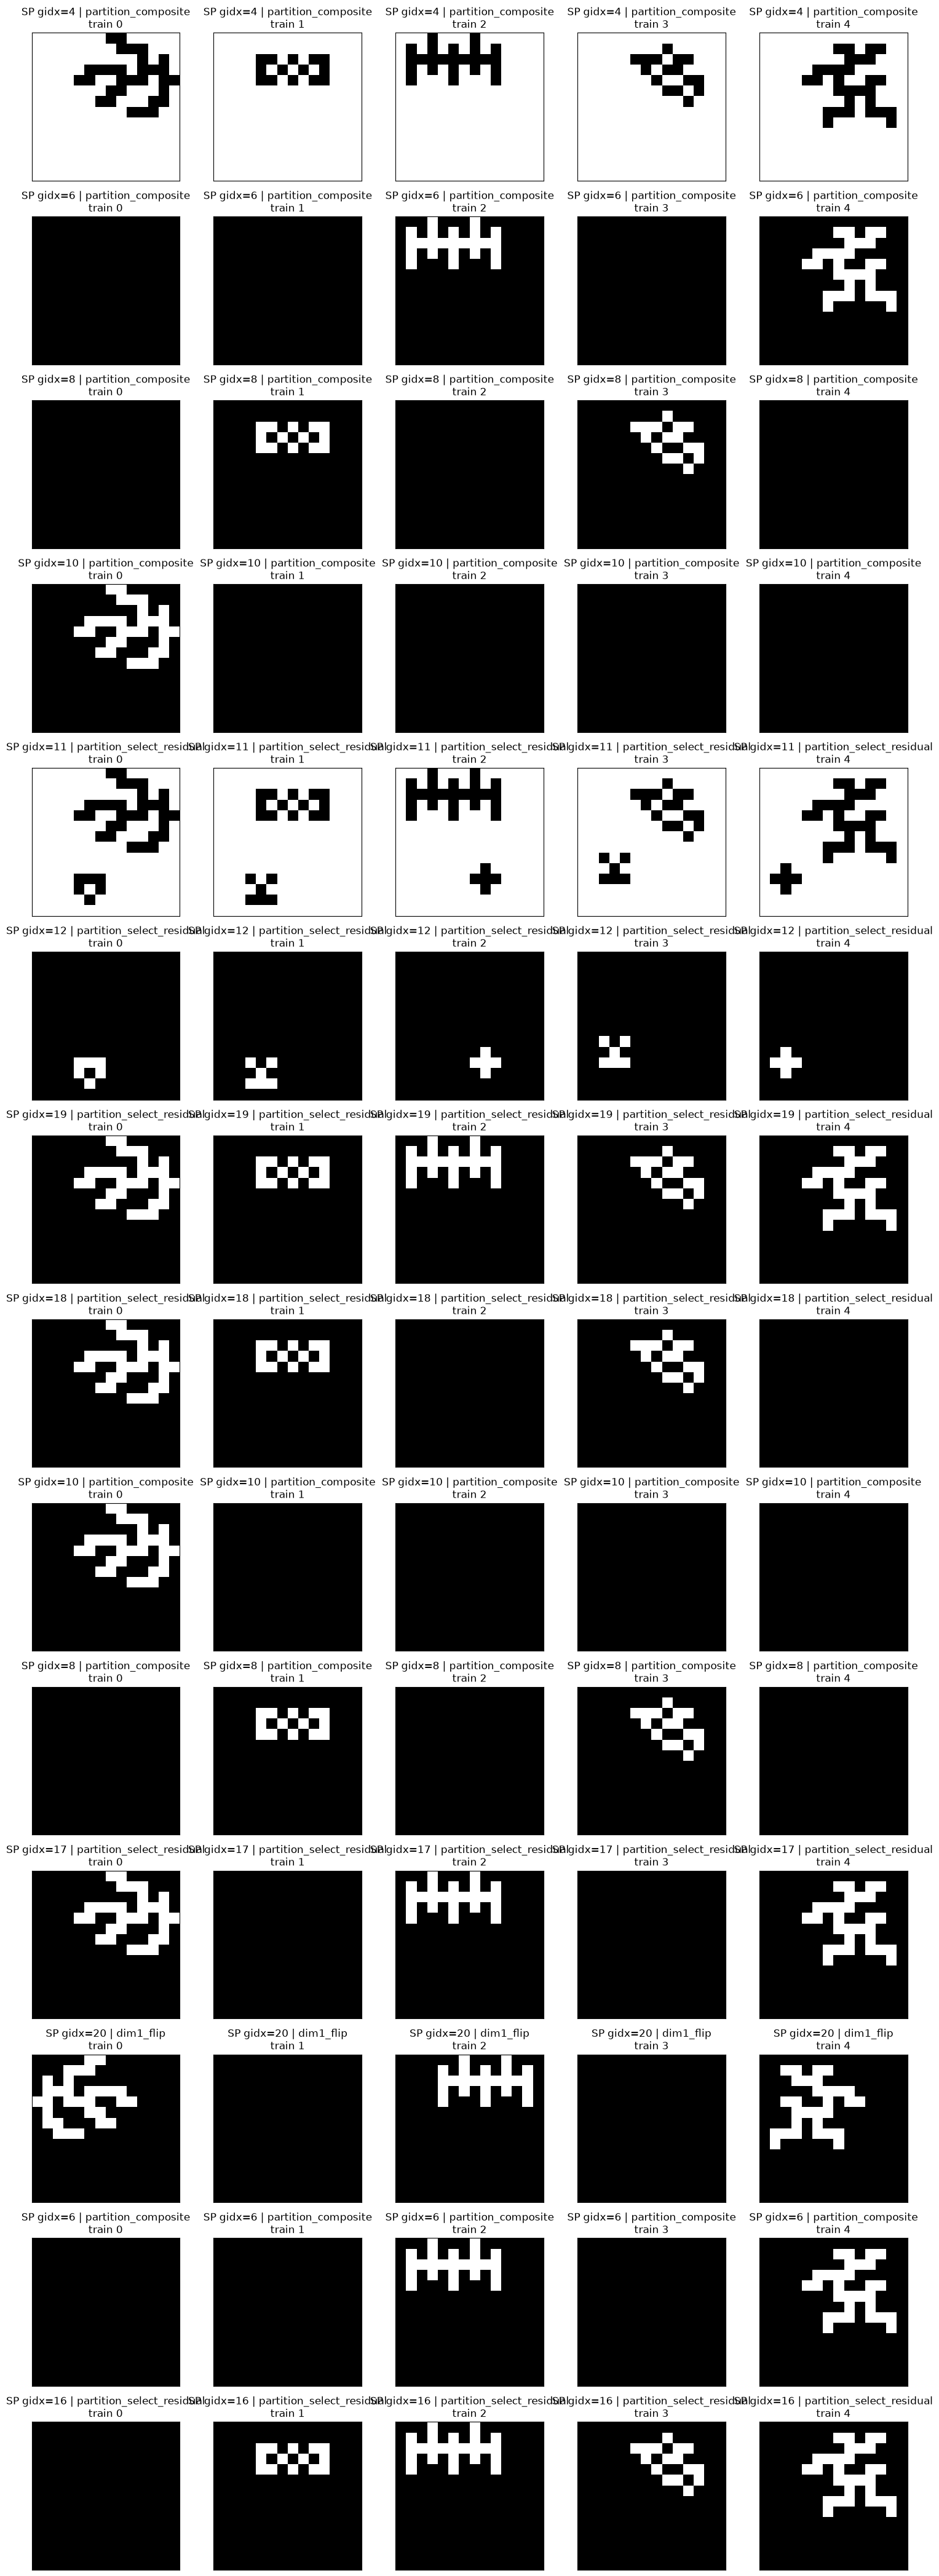

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def _gene_equal(a, b):
    return len(a) == len(b) and all(
        np.array_equal(np.asarray(x), np.asarray(y))
        for x, y in zip(a, b)
    )


def _find_gidx(gene, X):
    for gidx in range(len(X)):
        if _gene_equal(gene, X[gidx]):
            return gidx
    return None


def plot_bool_pool(pool, X, meta, label):
    if len(pool) == 0:
        print(f"No {label} 2D boolean genes.")
        return

    n_genes = len(pool)
    n_samples = X.sample_count

    fig, axes = plt.subplots(
        n_genes,
        n_samples,
        figsize=(3 * n_samples, 3 * n_genes),
        squeeze=False,
    )

    for row, gene in enumerate(pool):
        gidx = _find_gidx(gene, X)
        op = meta.op[gidx] if gidx is not None else "unknown"

        for sample_idx in range(n_samples):
            ax = axes[row, sample_idx]

            ax.imshow(
                np.asarray(gene[sample_idx], dtype=bool),
                cmap="gray",
                vmin=0,
                vmax=1,
                interpolation="nearest",
            )

            ax.set_title(
                f"{label} gidx={gidx} | {op}\n"
                f"train {sample_idx}"
            )
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


plot_bool_pool(
    GP_pool_2d_bool,
    GP_X,
    GP_meta,
    "GP",
)

plot_bool_pool(
    ST_frontier_2d_bool,
    SP_X,
    SP_meta,
    "SP",
)

In [11]:
display(
    pd.DataFrame(GP_meta.rows())
)

,gidx,source,op,dims,params
0,0,-1,raw_input,2,{}
1,1,0,partition_shape,0,{}
2,2,0,partition_shape,0,{}
3,3,0,partition_composite,0,{}
4,4,0,partition_composite,2,{}
...,...,...,...,...,...
64,64,"(8, 44)",bool2_intersect,2,{}
65,65,57,bool_complement,2,{}
66,66,6,dim1_flip,2,{}
67,67,11,bool_cavity,2,{}


In [12]:
from ops import Kelschinator

kelschinator = Kelschinator()

fit_success = kelschinator.fit(ST)

print("Fit success:", fit_success)

if not fit_success:
    print(kelschinator.last_error_)
else:
    y_hat = kelschinator.transform(task.test_inputs[0])

    print("Pipeline:")
    for step in kelschinator.pipeline_:
        print(" ", step)

    display(y_hat)

Fit success: False
SolutionTree is not fully solved.


In [13]:
import numpy as np

X_test = task.test_inputs[0]
Y_test = task.test_outputs[0]

y_hat = kelschinator.transform(X_test)

exact_match = np.array_equal(y_hat, Y_test)

print("Exact match:", exact_match)

if not exact_match:
    print("Differing cells:", np.count_nonzero(y_hat != Y_test))
    print("y_hat:")
    print(y_hat)
    print("Y_test:")
    print(Y_test)

RuntimeError: Kelschinator must be successfully fit before transform().